# ECON 4370 / BANA 4373 — Homework 4 Starter Notebook
## Difference-in-Differences: From Intuition to Estimation

**Posted:** Mar. 9  
**Due:** Mar. 23 (11:59 PM, Blackboard Ultra)

> **How to use this notebook:**
> - Replace every **TODO** with your answer (code or written response).
> - Keep written responses in **Markdown** cells. Keep code in **code** cells.
> - The notebook must run **top → bottom without errors** before you submit.
> - Save as `.ipynb` and upload to Blackboard Ultra.

---

### Context

You cannot always run a randomized experiment. When treatment is assigned by policy, geography, or circumstance rather than by a coin flip, **Difference-in-Differences (DiD)** is one of the most widely used tools for recovering a causal estimate.

In this homework you will:
1. Reconstruct the logic of DiD by hand from a 2×2 table.
2. Simulate calibrated panel data with a **known** treatment effect.
3. Estimate the DiD estimator both manually and via OLS regression.
4. Visualize the parallel trends assumption.
5. **Break the estimator** — violate parallel trends and observe the bias.
6. Apply the framework to a real policy context.

## Student Information
- **Name:** Anthony Bauer
- **Section / Time:** ECON 4370 9:30AM
- **NetID / Email:** awb022@shsu.edu

---
## 0) Setup — Imports and Folder Structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import os

# Reproducibility
np.random.seed(4373)

# Folder structure (mirrors course convention)
for folder in ["data_raw", "data_clean", "exports"]:
    os.makedirs(folder, exist_ok=True)

print("Setup complete.")

Setup complete.


---
# Part 1: The DiD Logic (No Code)

Answer the following questions in your own words. Keep each answer concise (2–4 sentences unless otherwise noted).

## Question 1 — The Fundamental Problem

Briefly explain why we cannot simply compare outcomes for treated units before and after a policy to measure its causal effect. What is the key counterfactual we are missing?

**Answer:** 
A simple before-after comparison is not enough because it mixes the treatment effect with any other time-varying force that affected the treated group, such as macroeconomic conditions or common trends. The missing counterfactual is the treated group's outcome in the post period if it had **not** received treatment. Because we never observe that outcome directly, we need a comparison group to approximate it.

## Question 2 — The 2×2 Table

The table below shows average employment rates (in percentage points) for two groups of counties before and after a minimum wage increase was introduced in the **treatment** group.

| | **Before** | **After** |
|---|---|---|
| **Treatment counties** | 62.0 | 65.5 |
| **Control counties** | 60.0 | 61.5 |

**(a)** What is the naïve before–after estimate for the treatment group?

**(b)** What is the control group's change over the same period?

**(c)** What is the DiD estimate? Show your arithmetic.

**(d)** Interpret the DiD estimate in a plain-English sentence. What does this number mean?

**Answer (a):** 65.5 − 62.0 = +3.5 pp

**Answer (b):** 61.5 − 60.0 = +1.5 pp

**Answer (c):** (65.5 − 62.0) − (61.5 − 60.0) = 3.5 − 1.5 = +2.0 pp

**Answer (d):** The DiD estimate is **+2.0 percentage points**. Interpreted causally, this means the policy increased employment in the treated group by 2.0 pp **relative to what would have happened absent treatment**, assuming parallel trends holds.

## Question 3 — Parallel Trends

**(a)** State the **parallel trends assumption** in your own words (1–2 sentences).

**(b)** Why can we **never fully verify** parallel trends using data alone?

**(c)** What visual evidence would make you *more* confident the assumption holds?

**Answer (a):** The parallel trends assumption says that, in the absence of treatment, the treated and control groups would have changed by the **same amount over time**. The groups do **not** need to have the same baseline level; what matters is that their untreated trends move in parallel.

**Answer (b):** We cannot test it directly because we never observe the treated group's untreated outcome in the post period. At best, we can look for evidence that makes the assumption more plausible.

**Answer (c):** The strongest visual evidence would be **multiple pre-treatment periods** in which the treated and control groups have similar slopes over time. If the lines move in parallel before treatment, that makes the DiD design more credible.

## Question 4 — Selection Bias Link

Recall the **SDO decomposition** from the potential outcomes lecture:

$$\text{SDO} = \text{ATE} + \underbrace{E[Y_i(0)|D_i=1] - E[Y_i(0)|D_i=0]}_{\text{Selection Bias}}$$

Explain in 2–3 sentences how DiD attempts to remove the selection bias term. What is it using the control group's trend to do?

**Answer:** 
DiD uses the control group's change over time as an estimate of the **counterfactual change** for the treated group. By differencing once, we remove time-invariant baseline gaps between groups; by differencing a second time, we net out common shocks that hit both groups. That is why DiD is often described as removing the level difference and the common time trend, leaving the treatment effect under parallel trends.

---
# Part 2: Simulating Panel Data with a Known Treatment Effect

You will now generate a **calibrated synthetic dataset** where we know the true causal effect. This lets you check whether your estimator recovers it.

### Context

Imagine a state job-training program rolled out in **Year 2** for a subset of counties. You observe each county in **Year 1** (pre-policy) and **Year 2** (post-policy). The outcome is the county-level employment rate (percentage points).

**Design parameters (do not change):**
- `N_counties = 200` — 100 treatment, 100 control
- `TRUE_ATT = 4.0` — the true causal effect (pp) you want to recover
- Treatment counties have a **higher baseline** employment rate (selection bias built in)
- Both groups share the **same time trend** (parallel trends holds by construction)

## Question 5 — Write Your Prior

**Before running any code**, answer the following:

**(a)** If you ignored the control group and only compared treatment counties before vs. after, would you expect to *over-estimate*, *under-estimate*, or *correctly estimate* the true effect of 4.0 pp? Why?

**(b)** If you used a cross-sectional comparison (treatment vs. control *only in Year 2*), would selection bias push your estimate up or down relative to the truth? Why?

**Prior (a):** **Over-estimate.** A before-after comparison for the treated group would capture both the true treatment effect (**+4.0 pp**) and the common time trend (**+2.0 pp**), so the estimate should be around **+6.0 pp** on average.

**Prior (b):** **Upward bias.** A post-period cross-sectional comparison still contains the pre-existing baseline gap between treated and control counties (**selection bias = +5.0 pp**). So it should overstate the true treatment effect.

## Question 6 — Simulate the Data

In [2]:
# ── Design parameters ──────────────────────────────────────────────────────
N_treat   = 100
N_control = 100
TRUE_ATT  = 4.0          # pp — the number we want to recover
COMMON_TREND = 2.0       # pp — shared time trend (same for both groups)
SELECTION_BIAS = 5.0     # pp — treatment counties start higher at baseline
NOISE_SD  = 3.0          # pp — county-level noise

# ── Build long-format panel ─────────────────────────────────────────────────
county_id  = list(range(N_treat + N_control))
treated    = [1] * N_treat + [0] * N_control

# Baseline (Year 1) employment rates
baseline_treat   = 62.0 + SELECTION_BIAS
baseline_control = 62.0

# County fixed effects (stable characteristic that shifts each county's baseline)
county_fe = np.concatenate([
    np.random.normal(baseline_treat,   NOISE_SD, N_treat),
    np.random.normal(baseline_control, NOISE_SD, N_control)
])

rows = []
for cid, treat, fe in zip(county_id, treated, county_fe):
    for year in [1, 2]:
        post = 1 if year == 2 else 0
        treatment_effect = TRUE_ATT if (post == 1 and treat == 1) else 0.0
        noise = np.random.normal(0, NOISE_SD)
        emp_rate = fe + COMMON_TREND * post + treatment_effect + noise
        rows.append({"county": cid, "year": year, "post": post,
                     "treated": treat, "emp_rate": emp_rate})

df = pd.DataFrame(rows)

# Save raw data
df.to_csv("data_raw/panel_simulated.csv", index=False)
print(f"Dataset shape: {df.shape}")
df.head(8)

Dataset shape: (400, 5)


,county,year,post,treated,emp_rate
0,0,1,0,1,68.480374
1,0,2,1,1,72.942196
2,1,1,0,1,70.626987
3,1,2,1,1,71.783893
4,2,1,0,1,65.092845
5,2,2,1,1,72.665682
6,3,1,0,1,72.921958
7,3,2,1,1,69.864334


**Briefly describe the dataset (2–3 sentences):** What does each row represent? How many rows are there total, and why?

**Answer:** Each row is a **county-year observation**. Because there are **200 counties** observed in **2 years**, the dataset has **400 rows** total. The data are in **long format**, so each county appears once in the pre period and once in the post period.

---
# Part 3: Naïve Estimates vs. DiD (Manual Calculation)

## Question 7 — Reconstruct the 2×2 Table

In [3]:
# TODO: Compute the mean employment rate for each of the 4 cells:
#   (treated=1, post=0), (treated=1, post=1),
#   (treated=0, post=0), (treated=0, post=1)
# Store results in variables named:
#   treat_pre, treat_post, ctrl_pre, ctrl_post

# YOUR CODE HERE

treat_pre  = df.loc[(df["treated"]==1) & (df["post"]==0), "emp_rate"].mean()
treat_post = df.loc[(df["treated"]==1) & (df["post"]==1), "emp_rate"].mean()
ctrl_pre   = df.loc[(df["treated"]==0) & (df["post"]==0), "emp_rate"].mean()
ctrl_post  = df.loc[(df["treated"]==0) & (df["post"]==1), "emp_rate"].mean()
print(f"Treated   | Before: {treat_pre:.2f}  After: {treat_post:.2f}")
print(f"Control   | Before: {ctrl_pre:.2f}  After: {ctrl_post:.2f}")

Treated   | Before: 67.41  After: 72.55
Control   | Before: 61.55  After: 64.33


## Question 8 — Three Estimators, Three Answers

In [4]:
# TODO: Compute the three estimators below and print them.

# 1. Naïve before–after for treated group only
naive_before_after = treat_post - treat_pre

# 2. Cross-sectional comparison (treated vs. control in post period only)
naive_cross_section = treat_post - ctrl_post

# 3. Difference-in-Differences estimator
did_manual = (treat_post - treat_pre) - (ctrl_post - ctrl_pre)

print(f"True ATT               : {TRUE_ATT:.2f}")
print(f"Naïve before-after     : {naive_before_after:.2f}")
print(f"Naïve cross-section    : {naive_cross_section:.2f}")
print(f"DiD (manual)           : {did_manual:.2f}")

True ATT               : 4.00
Naïve before-after     : 5.14
Naïve cross-section    : 8.22
DiD (manual)           : 2.35


**Interpret your results (3–4 sentences):** Which estimator comes closest to the true ATT? Are the naïve estimators biased in the direction you predicted in Question 5? Explain why each naïve estimate is off.

**Answer:** In this particular simulation, the manual DiD estimate is **2.35 pp**, which is below the true ATT of **4.0 pp**. That does **not** mean the estimator is wrong; it means this one simulated sample contains sampling noise. The naïve before-after estimate (**5.14 pp**) is too high because it includes the common trend, and the naïve cross-section estimate (**8.22 pp**) is too high because it still contains the baseline selection difference. DiD is the right estimator here because, across repeated samples, it is centered on the true ATT even if any single draw is not exact.

---
# Part 4: DiD via OLS Regression

The DiD estimator has an exact OLS representation. The regression we want is:

$$\text{emp\_rate}_{it} = \beta_0 + \beta_1 \cdot \text{post}_t + \beta_2 \cdot \text{treated}_i + \beta_3 \cdot (\text{post}_t \times \text{treated}_i) + \varepsilon_{it}$$

where $\hat{\beta}_3$ is the **DiD estimator**.

## Question 9 — Write Your Prior for β₃

Before running the regression, write down what you expect for $\hat{\beta}_3$ and why.

**Prior:** I expect \(\hat{\beta}_3\) to match the manual DiD estimate from Question 8 **exactly**, because in a 2×2 setup the interaction term in the regression reproduces the same DiD calculation algebraically. In this sample, that means it should be about **2.35 pp**, even though the true ATT is 4.0 pp.

## Question 10 — Run the DiD Regression

In [5]:
# TODO: Create the interaction term and run the OLS model.
# Use statsmodels formula API: smf.ols(formula, data=df).fit()
# Hint: the formula should include post, treated, and their interaction.

df["post_x_treated"] = df["post"] * df["treated"]

model = smf.ols("emp_rate ~ post + treated + post_x_treated"
                , data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               emp_rate   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     137.1
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           6.23e-61
Time:                        22:33:24   Log-Likelihood:                -1122.7
No. Observations:                 400   AIC:                             2253.
Df Residuals:                     396   BIC:                             2269.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         61.5473      0.403    152.

**Question 10a — Coefficient Interpretation:** In plain English, interpret each of the four coefficients ($\hat{\beta}_0$, $\hat{\beta}_1$, $\hat{\beta}_2$, $\hat{\beta}_3$). What does each one represent in the real-world context of this dataset?

**β̂₀ (intercept):** This is the average employment rate for the **control group in the pre period**, about **61.55**.

**β̂₁ (post):** This is the change from pre to post for the **control group**, about **+2.79 pp**. It captures the common time effect for untreated counties.

**β̂₂ (treated):** This is the baseline difference between **treated and control counties in the pre period**, about **+5.87 pp**. It is the selection gap that exists even before the policy.

**β̂₃ (post × treated):** This is the **Difference-in-Differences estimate**, about **+2.35 pp**. It measures how much more the treated group changed relative to the control group after the policy, and under parallel trends it is the causal treatment effect.

**Question 10b:** Does $\hat{\beta}_3$ match your manual DiD calculation from Question 8? Does it match the true ATT (4.0 pp)? Why might it not be exactly 4.0?

**Answer:** Yes. \(\hat{\beta}_3\) matches the manual DiD estimate from Question 8 essentially exactly (**2.35 pp**), which is what we expect in a 2×2 DiD design. It does **not** match the true ATT of **4.0 pp** in this one sample, but that is due to finite-sample noise, not bias in the estimator. The key point is that DiD is **unbiased on average** when parallel trends holds, even though any one realization can be above or below the truth.

---
# Part 5: Visualizing Parallel Trends

## Question 11 — The Parallel Trends Plot

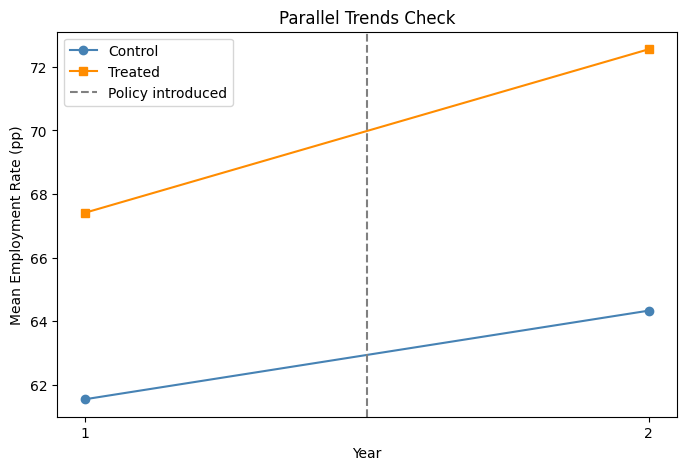

Figure saved.


In [6]:
# TODO: Create a line plot showing the mean employment rate by year
# for treated and control groups separately.
#
# Requirements:
#  - X-axis: year (1 and 2)
#  - Y-axis: mean employment rate
#  - Two lines: one for treated, one for control
#  - Add a vertical dashed line at year=1.5 labeled "Policy introduced"
#  - Label axes, add a legend, add a title
#  - Save the figure to exports/parallel_trends.png

# YOUR CODE HERE
means = df.groupby(["year", "treated"])["emp_rate"].mean().unstack()

plt.figure(figsize=(8, 5))
plt.plot([1, 2], means[0], "o-", label="Control", color="steelblue")
plt.plot([1, 2], means[1], "s-", label="Treated", color="darkorange")
plt.axvline(x=1.5, linestyle="--", color="gray", label="Policy introduced")
plt.xlabel("Year")
plt.ylabel("Mean Employment Rate (pp)")
plt.title("Parallel Trends Check")
plt.xticks([1, 2])
plt.legend()

plt.savefig("exports/parallel_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

**Describe your plot (2–3 sentences):** Does the visual evidence support the parallel trends assumption *before* the policy? What does the gap between the two lines in Year 2 suggest?

**Answer:** The plot shows that both groups rise between Year 1 and Year 2, while the treated group rises by a bit more. With only two periods we cannot truly inspect **pre-trends**, but visually the graph is consistent with the data-generating process in which both groups share the same untreated trend and the extra widening for the treated group reflects the treatment effect. In real applications, I would want several pre-treatment periods before feeling confident about parallel trends.

---
# Part 6: Break the Estimator — Violating Parallel Trends

> *"The best way to understand an assumption is to violate it on purpose."*

Now you will **deliberately break** the parallel trends assumption by introducing a pre-existing trend that differs across groups. This lets you see exactly how and how much the DiD estimator goes wrong.

## Question 12 — Write Your Prior Before Breaking

You are about to add an extra +3 pp trend to the treatment group *before* the policy (i.e., they were already trending upward more steeply). The true ATT remains 4.0 pp.

Before running the code: in which direction do you expect the **biased** DiD estimate to move (higher or lower than 4.0)? Why?

**Prior:** The biased DiD estimate should be **higher than 4.0**. If treated counties were already trending upward faster even without the policy, DiD will mistakenly attribute part of that extra growth to treatment. With an added **+3 pp** differential trend, I would expect the estimate to move upward toward roughly **7 pp** on average.

In [7]:
# ── Simulate broken data: treatment group has a steeper pre-trend ───────────
EXTRA_TREAT_TREND = 3.0   # pp — treatment group was already rising faster

rows_broken = []
for cid, treat, fe in zip(county_id, treated, county_fe):
    for year in [1, 2]:
        post = 1 if year == 2 else 0
        treatment_effect = TRUE_ATT if (post == 1 and treat == 1) else 0.0
        # Extra trend: treatment group trends up MORE even without the policy
        extra_trend = EXTRA_TREAT_TREND * post * treat
        noise = np.random.normal(0, NOISE_SD)
        emp_rate = fe + COMMON_TREND * post + extra_trend + treatment_effect + noise
        rows_broken.append({"county": cid, "year": year, "post": post,
                             "treated": treat, "emp_rate": emp_rate})

df_broken = pd.DataFrame(rows_broken)
df_broken["post_x_treated"] = df_broken["post"] * df_broken["treated"]

# Estimate DiD on the broken data
model_broken = smf.ols("emp_rate ~ post + treated + post_x_treated", data=df_broken).fit()

biased_estimate = model_broken.params["post_x_treated"]
print(f"True ATT        : {TRUE_ATT:.2f}")
print(f"Biased estimate : {biased_estimate:.2f}")
print(f"Bias            : {biased_estimate - TRUE_ATT:.2f} pp")

True ATT        : 4.00
Biased estimate : 6.62
Bias            : 2.62 pp


**Interpret the result (3–4 sentences):** Was the bias in the direction you predicted? Explain *mechanically* why the DiD estimator picks up the extra trend as part of the treatment effect. What would an applied economist need to rule this out?

**Answer:** Yes—the bias is in the predicted direction. The broken-sample DiD estimate is about **6.62 pp**, which is **2.62 pp above** the true ATT of 4.0. Mechanically, DiD treats any extra post-period change in the treated group as if it were caused by the policy, so when treated counties were already on a steeper path, that pre-existing trend gets loaded into the treatment coefficient. This is exactly why parallel trends is the core identifying assumption.

## Question 13 — Plot the Broken Parallel Trends

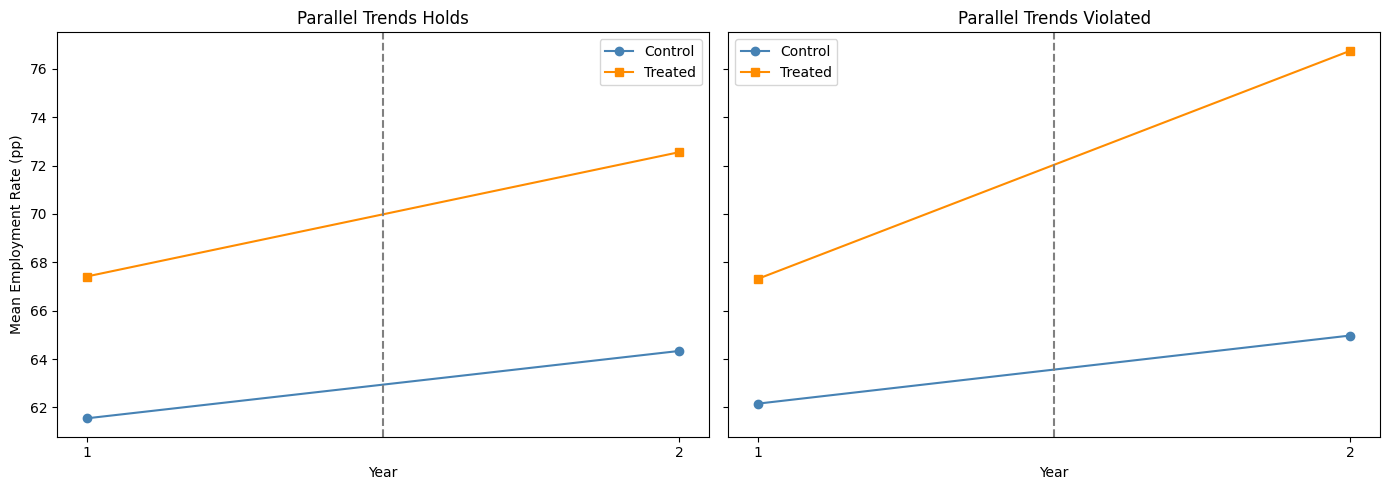

In [8]:
# TODO: Reproduce your parallel trends plot but using df_broken.
# Side-by-side subplots (1 row, 2 cols):
#   Left panel:  original data (df) — parallel trends holds
#   Right panel: broken data (df_broken) — parallel trends violated
# Each panel should have the same axis labels, a legend, and a title.
# Save to exports/parallel_trends_comparison.png

# YOUR CODE HERE

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left panel — original
means_orig = df.groupby(["year", "treated"])["emp_rate"].mean().unstack()
axes[0].plot([1, 2], means_orig[0], "o-", label="Control", color="steelblue")
axes[0].plot([1, 2], means_orig[1], "s-", label="Treated", color="darkorange")
axes[0].axvline(x=1.5, linestyle="--", color="gray")
axes[0].set_title("Parallel Trends Holds")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean Employment Rate (pp)")
axes[0].legend()
axes[0].set_xticks([1, 2])

# Right panel — broken
means_broken = df_broken.groupby(["year", "treated"])["emp_rate"].mean().unstack()
axes[1].plot([1, 2], means_broken[0], "o-", label="Control", color="steelblue")
axes[1].plot([1, 2], means_broken[1], "s-", label="Treated", color="darkorange")
axes[1].axvline(x=1.5, linestyle="--", color="gray")
axes[1].set_title("Parallel Trends Violated")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].set_xticks([1, 2])

plt.tight_layout()

**Describe what you see (2–3 sentences):** What is the visual difference between the two panels? How does this plot demonstrate the importance of the parallel trends assumption for the validity of the DiD estimator?

**Answer:** In the left panel, the treated and control groups move with roughly similar slopes, which is what we want under parallel trends. In the right panel, the treated line is visibly steeper, so the gap between groups widens even without a valid causal interpretation. That visual difference shows why the broken DiD estimate is biased upward: the estimator is picking up both the true treatment effect and the extra untreated trend in the treated group.

---
# Part 7: Real-World Application — Card & Krueger (1994)

Card and Krueger (1994) used DiD to study the effect of New Jersey's 1992 minimum wage increase on fast-food employment. New Jersey raised its minimum wage from \$4.25 to \$5.05; neighboring Pennsylvania did not. The table below reports their famous "Table 3" estimates (in full-time equivalent (FTE) employees per store):

| | **Before (Feb. 1992)** | **After (Nov. 1992)** | **Δ (After − Before)** |
|---|---|---|---|
| **New Jersey (treatment)** | 20.44 | 21.03 | +0.59 |
| **Pennsylvania (control)** | 23.33 | 21.17 | −2.16 |

Source: Card & Krueger (1994), *American Economic Review*, Table 3.

## Question 14 — Replicate the DiD Estimate

In [9]:
# TODO: Using the four values in the table above, compute
#   (a) the DiD estimate (as Card & Krueger report it)
#   (b) what NJ's employment would have been under the counterfactual
#       (i.e., if it had followed Pennsylvania's trend)

nj_before = 20.44
nj_after  = 21.03
pa_before = 23.33
pa_after  = 21.17

ck_did = (nj_after - nj_before) - (pa_after - pa_before)
nj_counterfactual = nj_before + (pa_after - pa_before)

print(f"Card–Krueger DiD estimate : {ck_did:.2f} FTE")
print(f"NJ counterfactual (post)  : {nj_counterfactual:.2f} FTE")

Card–Krueger DiD estimate : 2.75 FTE
NJ counterfactual (post)  : 18.28 FTE


**Interpret (3–5 sentences):** What does the DiD estimate tell us about the minimum wage increase's effect on fast-food employment in New Jersey? Why was this result surprising to many economists at the time? What is the role of Pennsylvania in this analysis?

**Answer:** The Card–Krueger DiD estimate is about **+2.75 FTE workers per store**. The Pennsylvania trend implies that, absent the policy, New Jersey employment would have fallen from **20.44** to about **18.28** FTE; instead, New Jersey rises to **21.03**. So relative to the counterfactual built from Pennsylvania, the minimum wage increase is associated with **higher**, not lower, fast-food employment. That result was influential because it challenged the simple textbook prediction that higher minimum wages must reduce employment.

## Question 15 — Threats to Identification

List **two** specific threats to the validity of the Card–Krueger DiD estimate. For each threat:
- Describe what would have to happen in the real world for it to be a problem.
- State whether it would bias the estimate **upward** or **downward** relative to the true effect.

**Threat 1:** **Differential local economic shocks (parallel trends violation)**  
- **Real-world scenario:** Suppose New Jersey's local economy was improving faster than Pennsylvania's for reasons unrelated to the minimum wage—stronger consumer demand, local development, or sector-specific growth. Then NJ fast-food employment would have risen relative to PA even without the policy.  
- **Direction of bias:** **Upward.** DiD would attribute part of NJ's independent improvement to the minimum wage.

**Threat 2:** **Spillovers across the border (control contamination / SUTVA violation)**  
- **Real-world scenario:** If workers or customers shifted across the NJ–PA border because of the wage change, Pennsylvania would no longer be a clean control group. For example, PA stores could lose workers or business as an indirect consequence of NJ's policy.  
- **Direction of bias:** Most likely **upward** if PA employment is pushed down by the spillover, because that would make the control trend look weaker and inflate NJ's relative gain.

---
# Part 8: Extension — How Robust is the Estimate? (Code + Interpretation)

## Question 16 — Sensitivity to Noise

Go back to the original simulated dataset. Re-run the simulation **50 times** (each time with a different random seed), saving the $\hat{\beta}_3$ from each run. Then:

**(a)** Plot a histogram of the 50 estimates.  
**(b)** Mark the true ATT (4.0 pp) with a vertical dashed line.  
**(c)** Report the mean and standard deviation of the 50 estimates.

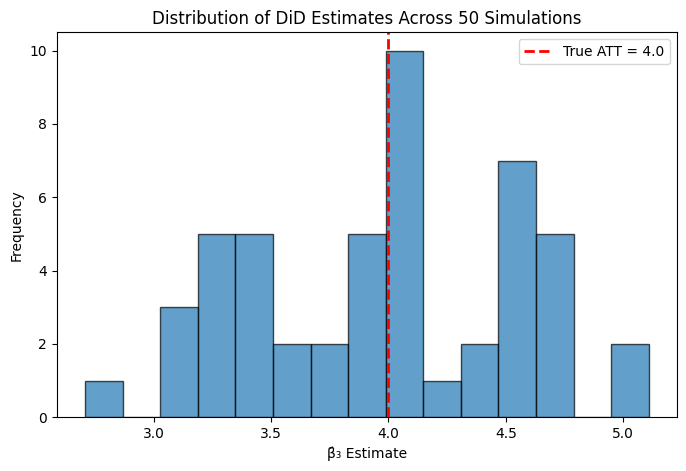

Mean of estimates : 3.99
Std of estimates  : 0.57


In [10]:
estimates = []

for seed in range(50):
    np.random.seed(seed)

    county_fe_sim = np.concatenate([
        np.random.normal(baseline_treat, NOISE_SD, N_treat),
        np.random.normal(baseline_control, NOISE_SD, N_control)
    ])

    rows_sim = []
    for cid, treat, fe in zip(county_id, treated, county_fe_sim):
        for year in [1, 2]:
            post = 1 if year == 2 else 0
            te = TRUE_ATT if (post == 1 and treat == 1) else 0.0
            noise = np.random.normal(0, NOISE_SD)
            emp = fe + COMMON_TREND * post + te + noise
            rows_sim.append({"county": cid, "year": year, "post": post,
                             "treated": treat, "emp_rate": emp})

    df_sim = pd.DataFrame(rows_sim)
    df_sim["post_x_treated"] = df_sim["post"] * df_sim["treated"]
    m = smf.ols("emp_rate ~ post + treated + post_x_treated", data=df_sim).fit()
    estimates.append(m.params["post_x_treated"])

estimates = np.array(estimates)

plt.figure(figsize=(8, 5))
plt.hist(estimates, bins=15, edgecolor="black", alpha=0.7)
plt.axvline(x=TRUE_ATT, linestyle="--", color="red", linewidth=2, label=f"True ATT = {TRUE_ATT}")
plt.xlabel("β̂₃ Estimate")
plt.ylabel("Frequency")
plt.title("Distribution of DiD Estimates Across 50 Simulations")
plt.legend()

plt.savefig("exports/sensitivity_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean of estimates : {estimates.mean():.2f}")
print(f"Std of estimates  : {estimates.std():.2f}")

**Interpret (2–3 sentences):** Is the DiD estimator *unbiased* (centered near 4.0)? What does the spread of the distribution tell you about uncertainty when applying DiD to real data?

**Answer:** The repeated-sampling exercise shows exactly what unbiasedness means in practice: the distribution of estimates is centered very close to the true value (**mean ≈ 3.99**, true ATT = **4.0**). At the same time, there is visible dispersion (**std ≈ 0.57**), so any one dataset can still produce an estimate that is meaningfully above or below the truth. In applied work, that is why standard errors, confidence intervals, and statistical significance matter—sampling variation is real even when the identification strategy is correct.

---
# Part 9: Reflection

## Question 17 — Synthesis (6–8 sentences)

Reflect on the following:

1. What makes DiD more convincing than a simple before–after comparison?
2. In what situations would you *not* trust a DiD estimate, even if the parallel trends plot looks good?
3. How does the simulation exercise (knowing the true ATT) help you build intuition that you cannot get from real data alone?

**Reflection:** Difference-in-Differences improves on a simple before-after comparison because it uses the control group's change over time to build the missing counterfactual for the treated group. The first difference removes fixed baseline gaps between groups, and the second difference removes shocks that are common to both groups. Under parallel trends, the remaining difference isolates the causal effect of the treatment.

But the method is only as credible as its identifying assumptions. A plot that looks good is helpful, but it does not prove validity because anticipation effects, spillovers, or compositional changes can still bias the estimate. The simulation makes that point very clearly: when parallel trends holds, repeated DiD estimates are centered on the truth; when we intentionally violate it, the estimator moves systematically away from the true ATT. That is the main lesson of the assignment—DiD is powerful, but only when we can defend the counterfactual.

---
## Final Export

In [11]:
# Save the cleaned panel to data_clean/
df.to_csv("data_clean/panel_clean.csv", index=False)
print("Clean data saved to data_clean/panel_clean.csv")
print("\nExports folder contents:")
for f in sorted(os.listdir("exports")):
    print(" ", f)

Clean data saved to data_clean/panel_clean.csv

Exports folder contents:
  parallel_trends.png
  sensitivity_histogram.png


---
## Submission Checklist

Before uploading to Blackboard, confirm:

- [ ] Notebook runs **top → bottom without errors**
- [ ] Every **TODO** replaced with a real answer
- [ ] Both figures saved in `exports/` (parallel trends + comparison)
- [ ] Written answers are in **Markdown cells** (not code comments)
- [ ] Saved as **`.ipynb`** and uploaded to Blackboard Ultra

---
### Further Reading (Optional)
- **Cunningham (2021)**, *Causal Inference: The Mixtape*, Ch. 9 (DiD) — free at [mixtape.scunning.com](https://mixtape.scunning.com)  
- **Card & Krueger (1994)**, "Minimum Wages and Employment," *American Economic Review*  
- **Angrist & Pischke (2009)**, *Mostly Harmless Econometrics*, Ch. 5